# MCDI504 - Machine Learning I
## Avance del Proyecto · Fase 1: Definición y orientación de la situación

**Notebook:** `F1_Definicion.ipynb`

**Caso:** Red Nacional de Monitoreo de Biodiversidad (RNMB)

**Grupo:** GRUPO1

**Integrantes:**
- Pablo Ignacio Balbontín Constenla
- Melany Esmeralda Reyes Leiva
- Ingeborg Andrea Muñoz Carnot
- Mario Alejandro López Pulgar

**Fecha:** Agosto 2026

---

Este notebook constituye la evidencia computacional de la Fase 1. **No entrena modelos**: formaliza el
problema en un entorno reproducible y ejecuta el flujo de análisis exploratorio y preparación de datos
establecido en el material de la asignatura (Ruete, 2026c).

## 1. Definición del problema

La Red Nacional de Monitoreo de Biodiversidad (RNMB) opera estaciones de terreno donde brigadas
técnicas y voluntarios formados registran mediciones morfométricas de los ejemplares observados. Para
que un registro ingrese a la base de datos de la red debe llevar asociada la especie determinada.

La determinación taxonómica está a cargo de un equipo reducido de especialistas. Tras la incorporación
de voluntarios a las campañas, el volumen de registros creció por encima de la capacidad de ese
equipo, y hoy existe un rezago de registros medidos pero sin determinar. Un registro sin especie es un
dato inutilizable: no ingresa a los análisis de distribución ni a los reportes de la red.

**Problema analítico.** Determinar si las mediciones morfométricas que las brigadas ya registran de
forma rutinaria contienen información suficiente para asignar la especie de un ejemplar de manera
automática, y establecer qué tipo de aprendizaje corresponde a esa tarea.

**Pregunta analítica.** ¿Permiten las mediciones de largo y ancho de sépalo y pétalo determinar la
especie de un ejemplar, considerando que la red dispone de un histórico de registros ya determinados
por especialistas?

**Datos.** Se utiliza el conjunto Iris (Fisher, 1936), cargado desde `scikit-learn` mediante
`load_iris()`. Su estructura reproduce la del problema: cuatro mediciones morfométricas continuas y la
especie determinada por experto para cada ejemplar.

## 2. Objetivos

**Objetivo general.** Formalizar computacionalmente la definición del problema y generar la evidencia
estadística que fundamenta la selección del enfoque de aprendizaje, sin desarrollar modelamiento.

**Objetivos específicos.**

1. Cargar el conjunto de datos y caracterizar su estructura, tipos de variables y dimensiones.
2. Describir estadísticamente las variables y verificar la completitud de los registros.
3. Visualizar la distribución de las variables de entrada e identificar valores atípicos.
4. Transformar la variable de decisión para habilitar el análisis de correlación.
5. Cuantificar las asociaciones lineales mediante el coeficiente de Pearson.
6. Normalizar las variables de entrada al rango [0, 1].
7. Evaluar la significancia estadística de las asociaciones mediante p-valores.

## 3. Estructura del flujo y correspondencia con KDD

| Bloque | Etapa KDD | Evidencia que produce |
|---|---|---|
| 4. Librerías | — | Entorno de trabajo |
| 5. Carga de la base | Selección | `bbdd1` (150 × 5) |
| 6. Análisis descriptivo | Preprocesamiento | Resumen estadístico y estructura |
| 7. Boxplot | Preprocesamiento | Distribución y valores atípicos |
| 8. Transformación de `Species` | Transformación | `bbdd2` |
| 9. Correlación de Pearson | Transformación | Matriz y mapa de calor |
| 10. Normalización | Transformación | `bbdd_norm_completa` |
| 11. P-valores | Interpretación | Matriz de significancia |

La etapa de **minería de datos** queda fuera del alcance de esta fase y se desarrollará en F2–F4.

## 4. Librerías necesarias

Importamos las librerías que usaremos para el análisis.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler

In [2]:
import os

# Carpeta de salida para las figuras (ruta relativa a notebooks/, apunta a
# la carpeta figures/ en la raiz del proyecto, ya versionada con .gitkeep)
FIGURES_DIR = os.path.join("..", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

## 5. Cargar base de datos  ·  *KDD: Selección*

Cargamos el conjunto de datos desde `sklearn.datasets` y lo convertimos a un DataFrame de pandas,
conservando `Species` como variable categórica.

In [3]:
iris = load_iris()

bbdd1 = pd.DataFrame(
    iris.data,
    columns=[
        "Sepal.Length",
        "Sepal.Width",
        "Petal.Length",
        "Petal.Width"
    ]
)

# Agregar variable de decisión Species como categórica
bbdd1["Species"] = pd.Categorical.from_codes(
    iris.target,
    iris.target_names
)

## 6. Análisis descriptivo inicial  ·  *KDD: Preprocesamiento*

Realizamos un análisis descriptivo de las variables de entrada y la variable de decisión `Species`.

In [4]:
print("Resumen estadístico:")
print(bbdd1.describe(include="all"))

print("\nEstructura de la base de datos:")
print(bbdd1.info())

Resumen estadístico:
        Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
count     150.000000   150.000000    150.000000   150.000000     150
unique           NaN          NaN           NaN          NaN       3
top              NaN          NaN           NaN          NaN  setosa
freq             NaN          NaN           NaN          NaN      50
mean        5.843333     3.057333      3.758000     1.199333     NaN
std         0.828066     0.435866      1.765298     0.762238     NaN
min         4.300000     2.000000      1.000000     0.100000     NaN
25%         5.100000     2.800000      1.600000     0.300000     NaN
50%         5.800000     3.000000      4.350000     1.300000     NaN
75%         6.400000     3.300000      5.100000     1.800000     NaN
max         7.900000     4.400000      6.900000     2.500000     NaN

Estructura de la base de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column   

In [5]:
print("Resumen estadístico:")
print(bbdd1.describe())

print("\nEstructura de la base de datos:")
print(bbdd1.info())

Resumen estadístico:
       Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Estructura de la base de datos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Sepal.Length  150 non-null    float64 
 1   Sepal.Width   150 non-null    float64 
 2   Petal.Length  150 non-null    float64 
 3   Petal.Width   150 non-null    float64 
 4   Species       150 non-null    cat

## 7. Visualización de la distribución con Boxplot  ·  *KDD: Preprocesamiento*

Un boxplot nos ayuda a visualizar la distribución de las variables numéricas y a identificar
posibles *outliers*.

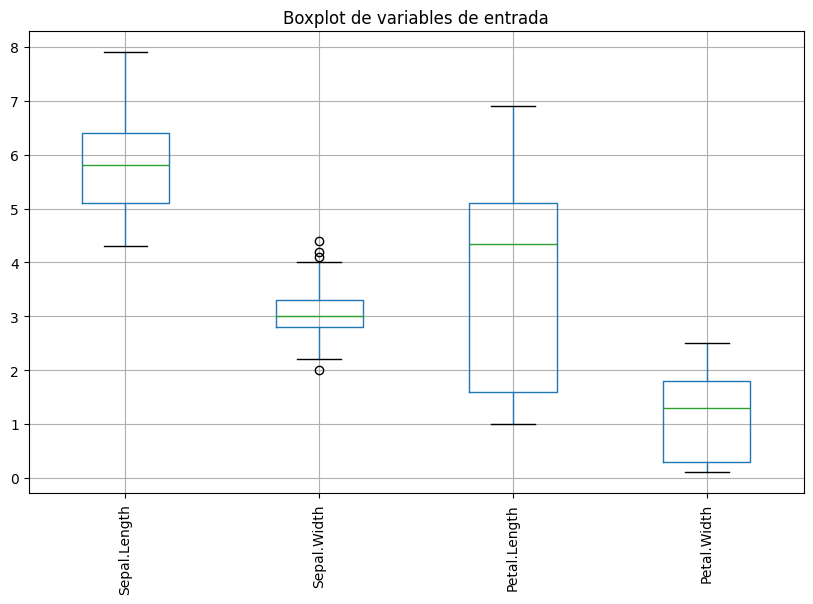

In [6]:
plt.figure(figsize=(10, 6))
bbdd1.iloc[:, 0:4].boxplot()
plt.xticks(rotation=90)
plt.xlabel("")
plt.ylabel("")
plt.title("Boxplot de variables de entrada")
plt.savefig(os.path.join(FIGURES_DIR, "boxplot_variables.png"), dpi=300, bbox_inches="tight")
plt.show()

## 8. Transformación de la variable `Species`  ·  *KDD: Transformación*

Convertimos la variable categórica `Species` a un formato numérico para poder calcular correlaciones.

In [7]:
bbdd2 = bbdd1.copy()

bbdd2["Species"] = bbdd2["Species"].cat.codes + 1
# Se suma +1 para imitar el comportamiento de R,
# donde las categorías se codifican como 1, 2 y 3.
# En Python normalmente serían 0, 1 y 2.

### Revisión y resumen de `bbdd2`

Verificamos la estructura y el resumen estadístico de la nueva base de datos con `Species` numérica.

In [8]:
print("\nEstructura de bbdd2:")
print(bbdd2.info())

print("\nResumen estadístico de bbdd2:")
print(bbdd2.describe())


Estructura de bbdd2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal.Length  150 non-null    float64
 1   Sepal.Width   150 non-null    float64
 2   Petal.Length  150 non-null    float64
 3   Petal.Width   150 non-null    float64
 4   Species       150 non-null    int8   
dtypes: float64(4), int8(1)
memory usage: 5.0 KB
None

Resumen estadístico de bbdd2:
       Sepal.Length  Sepal.Width  Petal.Length  Petal.Width     Species
count    150.000000   150.000000    150.000000   150.000000  150.000000
mean       5.843333     3.057333      3.758000     1.199333    2.000000
std        0.828066     0.435866      1.765298     0.762238    0.819232
min        4.300000     2.000000      1.000000     0.100000    1.000000
25%        5.100000     2.800000      1.600000     0.300000    1.000000
50%        5.800000     3.000000      4.350000     1.300

## 9. Matriz de correlación  ·  *KDD: Transformación*

Calculamos y visualizamos la matriz de correlación de Pearson para entender la relación entre las
variables.

In [9]:
correlacion = bbdd2.corr(method="pearson")

print("\nMatriz de correlación:")
print(correlacion)


Matriz de correlación:
              Sepal.Length  Sepal.Width  Petal.Length  Petal.Width   Species
Sepal.Length      1.000000    -0.117570      0.871754     0.817941  0.782561
Sepal.Width      -0.117570     1.000000     -0.428440    -0.366126 -0.426658
Petal.Length      0.871754    -0.428440      1.000000     0.962865  0.949035
Petal.Width       0.817941    -0.366126      0.962865     1.000000  0.956547
Species           0.782561    -0.426658      0.949035     0.956547  1.000000


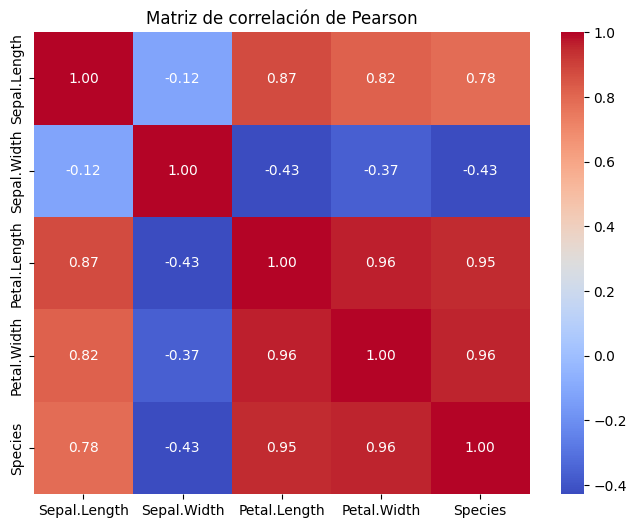

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación de Pearson")
plt.savefig(os.path.join(FIGURES_DIR, "correlacion_pearson.png"), dpi=300, bbox_inches="tight")
plt.show()

## 10. Normalización de datos  ·  *KDD: Transformación*

Normalizamos las variables numéricas para escalar sus valores entre 0 y 1, lo cual es útil para
ciertos modelos de machine learning.

In [11]:
# Seleccionar variables de entrada
bbdd = bbdd2.iloc[:, 0:4]

In [12]:
scaler = MinMaxScaler()

bbdd_norm = pd.DataFrame(
    scaler.fit_transform(bbdd),
    columns=bbdd.columns
)

### Reintegración de la variable `Species` original

Separamos la variable `Species` original y la unimos con las variables normalizadas.

In [13]:
Species = bbdd1[["Species"]]

In [14]:
bbdd_norm_completa = pd.concat(
    [bbdd_norm, Species],
    axis=1
)

### Base de datos normalizada completa

Mostramos las primeras filas y el resumen estadístico de la base de datos con todas las variables
normalizadas y `Species` original.

In [15]:
print("\nBase de datos normalizada completa:")
print(bbdd_norm_completa.head())

print("\nResumen estadístico de base normalizada:")
print(bbdd_norm_completa.describe())


Base de datos normalizada completa:
   Sepal.Length  Sepal.Width  Petal.Length  Petal.Width Species
0      0.222222     0.625000      0.067797     0.041667  setosa
1      0.166667     0.416667      0.067797     0.041667  setosa
2      0.111111     0.500000      0.050847     0.041667  setosa
3      0.083333     0.458333      0.084746     0.041667  setosa
4      0.194444     0.666667      0.067797     0.041667  setosa

Resumen estadístico de base normalizada:
       Sepal.Length  Sepal.Width  Petal.Length  Petal.Width
count    150.000000   150.000000    150.000000   150.000000
mean       0.428704     0.440556      0.467458     0.458056
std        0.230018     0.181611      0.299203     0.317599
min        0.000000     0.000000      0.000000     0.000000
25%        0.222222     0.333333      0.101695     0.083333
50%        0.416667     0.416667      0.567797     0.500000
75%        0.583333     0.541667      0.694915     0.708333
max        1.000000     1.000000      1.000000     1.0000

## 11. Matriz de p-valores para la correlación de Pearson  ·  *KDD: Interpretación*

Podemos calcular los p-valores asociados a cada coeficiente de correlación de Pearson. Un p-valor bajo
(típicamente < 0.05) sugiere que la correlación es estadísticamente significativa.

In [16]:
from scipy.stats import pearsonr

def calculate_pvalues(df):
    df = df.dropna()._get_numeric_data() # dropna() to handle missing values and select only numeric columns
    df_cols = df.columns
    pvalues = pd.DataFrame(np.ones(shape=(len(df_cols), len(df_cols))), columns=df_cols, index=df_cols)
    for col1 in df_cols:
        for col2 in df_cols:
            if col1 == col2:
                pvalues.loc[col1, col2] = 0.0 # p-value for correlation with itself is 0
            else:
                _, p = pearsonr(df[col1], df[col2])
                pvalues.loc[col1, col2] = p
    return pvalues

# Calcular la matriz de p-valores para bbdd2
pvalue_matrix = calculate_pvalues(bbdd2)

print("\nMatriz de p-valores (Correlación de Pearson):")
print(pvalue_matrix)


Matriz de p-valores (Correlación de Pearson):
              Sepal.Length   Sepal.Width  Petal.Length   Petal.Width  \
Sepal.Length  0.000000e+00  1.518983e-01  1.038667e-47  2.325498e-37   
Sepal.Width   1.518983e-01  0.000000e+00  4.513314e-08  4.073229e-06   
Petal.Length  1.038667e-47  4.513314e-08  0.000000e+00  4.675004e-86   
Petal.Width   2.325498e-37  4.073229e-06  4.675004e-86  0.000000e+00   
Species       2.890478e-32  5.201563e-08  4.201873e-76  4.155311e-81   

                   Species  
Sepal.Length  2.890478e-32  
Sepal.Width   5.201563e-08  
Petal.Length  4.201873e-76  
Petal.Width   4.155311e-81  
Species       0.000000e+00  


### Visualización de la matriz de p-valores

También podemos visualizar la matriz de p-valores, similar a cómo visualizamos la matriz de
correlación, para identificar rápidamente las relaciones significativas.

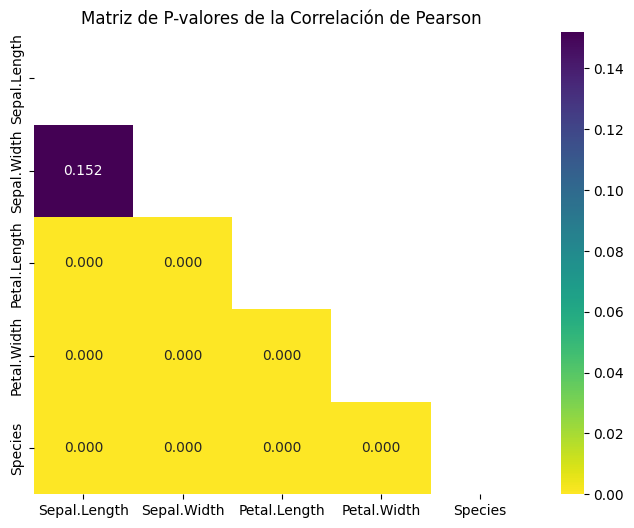

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    pvalue_matrix,
    annot=True,
    cmap="viridis_r", # Using a reversed viridis colormap to highlight low p-values
    fmt=".3f",
    mask=np.triu(np.ones_like(pvalue_matrix, dtype=bool)) # Mask the upper triangle for clarity
)
plt.title("Matriz de P-valores de la Correlación de Pearson")
plt.savefig(os.path.join(FIGURES_DIR, "pvalores_pearson.png"), dpi=300, bbox_inches="tight")
plt.show()

## 12. Correspondencia con el enfoque de aprendizaje

La evidencia generada por este flujo sustenta la decisión metodológica declarada en el informe:

| Criterio | Evidencia en este notebook | Decisión |
|---|---|---|
| Existencia de variable objetivo | `describe(include="all")` e `info()` muestran `Species` con 150 registros no nulos | Aprendizaje **supervisado** |
| Tipo de variable objetivo | `Species` es categórica con 3 valores únicos y frecuencia 50 en la clase más común | **Clasificación multiclase** |
| Tipo de variables predictoras | 4 columnas `float64` continuas | Entradas cuantitativas |
| Propósito analítico | Asignar especie a partir de mediciones | Predicción de clase |
| Condición de los datos | 150 registros no nulos en las 5 columnas; clases balanceadas | Base apta para F2-F4 |

**Enfoque seleccionado:** aprendizaje supervisado de clasificación multiclase.
**Etapas KDD cubiertas:** selección, preprocesamiento y transformación, con lectura interpretativa
inicial. La minería de datos se desarrollará en las fases F2 a F4.